In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv('air_quality_dataset_lstm-1.csv')

In [14]:
df.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,NaN,NaN,1.00,40.01,36.37,NaN,1.00,122.07,NaN,0.0,0.0,0.0,NaN,NaN
1,Ahmedabad,2015-01-01 02:00:00,NaN,NaN,0.02,27.75,19.73,NaN,0.02,85.90,NaN,0.0,0.0,0.0,NaN,NaN
2,Ahmedabad,2015-01-01 03:00:00,NaN,NaN,0.08,19.32,11.08,NaN,0.08,52.83,NaN,0.0,0.0,0.0,NaN,NaN
3,Ahmedabad,2015-01-01 04:00:00,NaN,NaN,0.30,16.45,9.20,NaN,0.30,39.53,153.58,0.0,0.0,0.0,NaN,NaN
4,Ahmedabad,2015-01-01 05:00:00,NaN,NaN,0.12,14.90,7.85,NaN,0.12,32.63,NaN,0.0,0.0,0.0,NaN,NaN


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 707875 entries, 0 to 707874
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   City        707875 non-null  object 
 1   Datetime    707875 non-null  object 
 2   PM2.5       562787 non-null  float64
 3   PM10        411138 non-null  float64
 4   NO          591243 non-null  float64
 5   NO2         590753 non-null  float64
 6   NOx         584651 non-null  float64
 7   NH3         435333 non-null  float64
 8   CO          621358 non-null  float64
 9   SO2         577502 non-null  float64
 10  O3          578667 non-null  float64
 11  Benzene     544229 non-null  float64
 12  Toluene     487268 non-null  float64
 13  Xylene      252046 non-null  float64
 14  AQI         578795 non-null  float64
 15  AQI_Bucket  578795 non-null  object 
dtypes: float64(13), object(3)
memory usage: 86.4+ MB


In [16]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,562787.000000,411138.000000,591243.000000,590753.000000,584651.000000,435333.000000,621358.000000,577502.000000,578667.000000,544229.000000,487268.000000,252046.000000,578795.000000
mean,67.622994,119.075804,17.421755,28.885157,32.287565,23.607959,2.183539,14.038307,34.798979,3.087595,8.660927,3.130537,166.413500
std,74.730496,104.224752,32.095211,29.162194,39.756669,28.831900,10.970514,19.305540,29.806379,16.456599,21.741023,7.834832,162.112729
min,0.010000,0.010000,0.010000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,8.000000
25%,26.200000,52.380000,3.840000,10.810000,10.660000,8.120000,0.420000,4.880000,13.420000,0.050000,0.370000,0.100000,79.000000
50%,46.420000,91.500000,7.960000,20.320000,20.790000,15.380000,0.800000,8.370000,26.240000,0.860000,2.590000,0.790000,116.000000
75%,79.490000,147.520000,16.150000,36.350000,37.150000,29.230000,1.370000,14.780000,47.620000,2.750000,8.410000,3.120000,208.000000
max,999.990000,1000.000000,499.990000,499.510000,498.610000,499.970000,498.570000,199.960000,497.620000,498.070000,499.400000,499.990000,3133.000000


In [17]:
df.isnull().sum()

,0
City,0
Datetime,0
PM2.5,145088
PM10,296737
NO,116632
NO2,117122
NOx,123224
NH3,272542
CO,86517
SO2,130373


In [18]:
df.duplicated().sum()

np.int64(0)

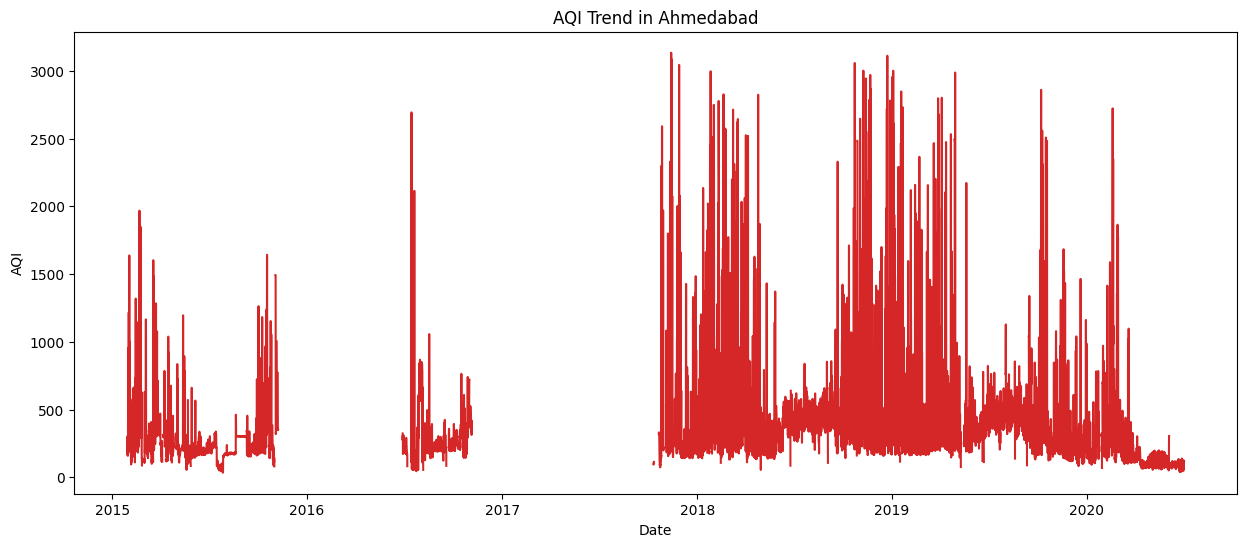

In [80]:
# 1. Visualize AQI Trend for Ahmedabad
city_name = 'Ahmedabad'
city_df = df[df['City'] == city_name].sort_values('Datetime')

plt.figure(figsize=(15, 6))
plt.plot(city_df['Datetime'], city_df['AQI'], color='tab:red')
plt.title(f'AQI Trend in {city_name}')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.savefig('aqi_trend_ahmedabad.png')
plt.show()

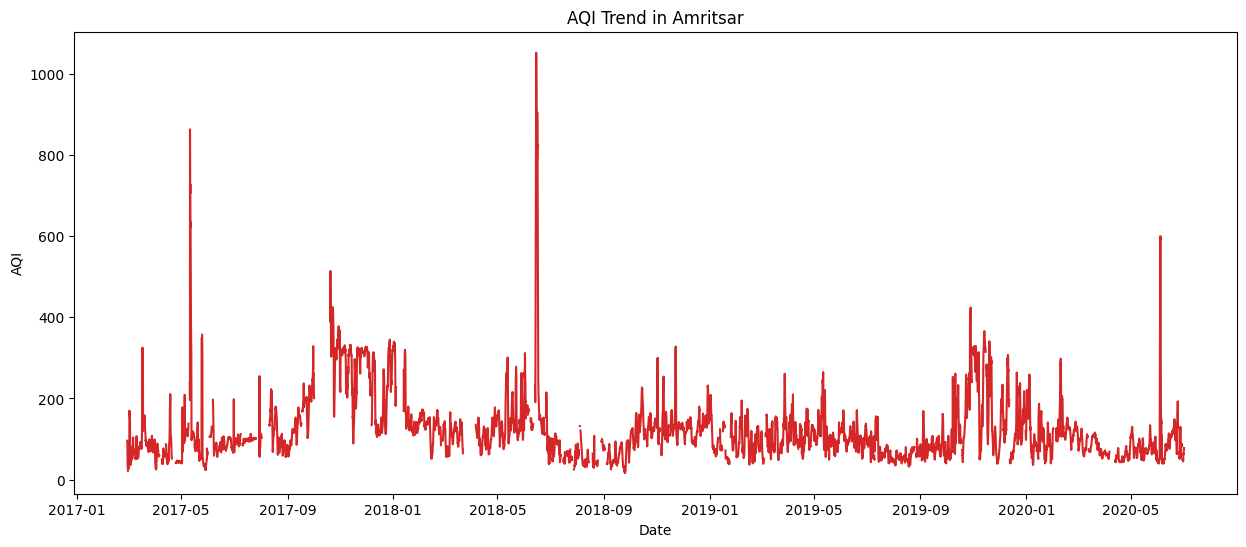

In [81]:
# 1. Visualize AQI Trend for Amritsar
city_name = 'Amritsar'
city_df = df[df['City'] == city_name].sort_values('Datetime')

plt.figure(figsize=(15, 6))
plt.plot(city_df['Datetime'], city_df['AQI'], color='tab:red')
plt.title(f'AQI Trend in {city_name}')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.savefig('aqi_trend_Amritsar.png')
plt.show()

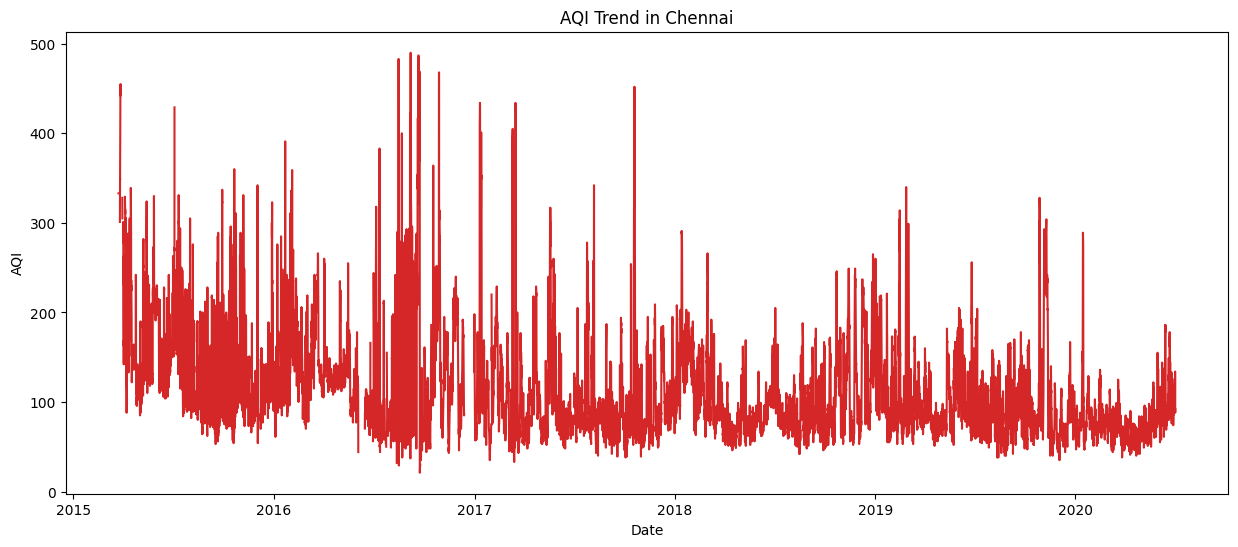

In [82]:
# 1. Visualize AQI Trend for Chennai
city_name = 'Chennai'
city_df = df[df['City'] == city_name].sort_values('Datetime')

plt.figure(figsize=(15, 6))
plt.plot(city_df['Datetime'], city_df['AQI'], color='tab:red')
plt.title(f'AQI Trend in {city_name}')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.savefig('aqi_trend_Chennai.png')
plt.show()

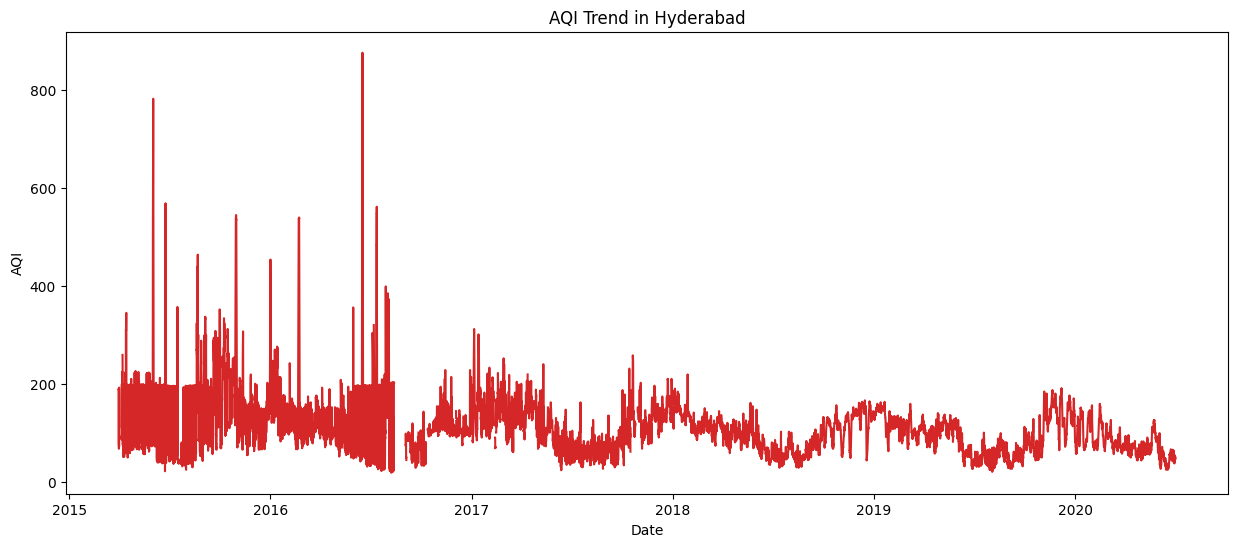

In [83]:
# 1. Visualize AQI Trend for Hyderabad
city_name = 'Hyderabad'
city_df = df[df['City'] == city_name].sort_values('Datetime')

plt.figure(figsize=(15, 6))
plt.plot(city_df['Datetime'], city_df['AQI'], color='tab:red')
plt.title(f'AQI Trend in {city_name}')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.savefig('aqi_trend_Hyderabad.png')
plt.show()

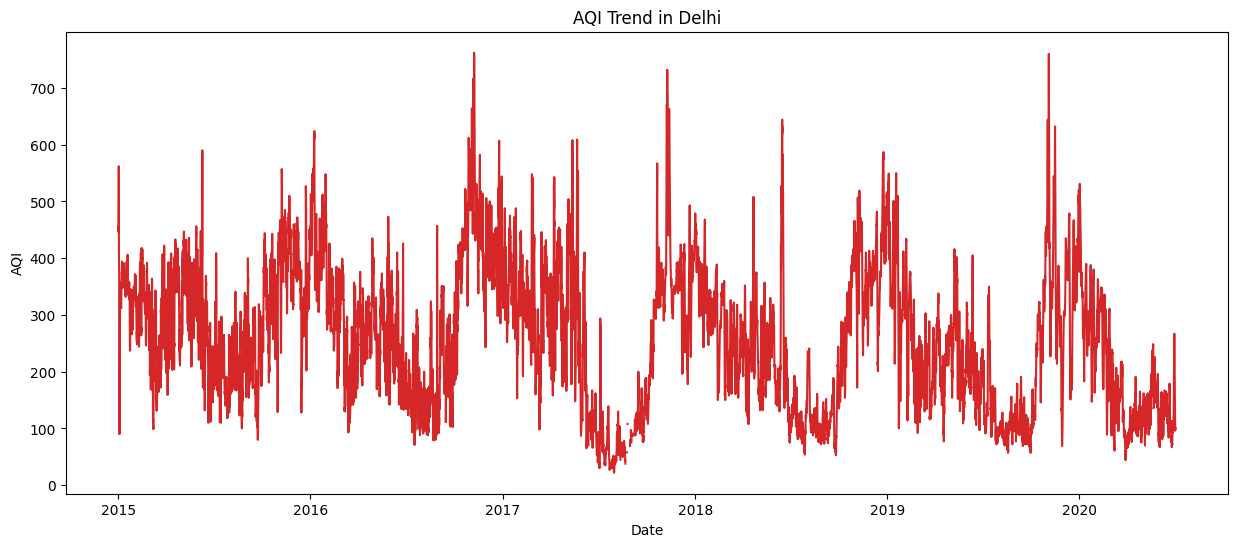

In [84]:
# 1. Visualize AQI Trend for Delhi
city_name = 'Delhi'
city_df = df[df['City'] == city_name].sort_values('Datetime')

plt.figure(figsize=(15, 6))
plt.plot(city_df['Datetime'], city_df['AQI'], color='tab:red')
plt.title(f'AQI Trend in {city_name}')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.savefig('aqi_trend_Delhi.png')
plt.show()

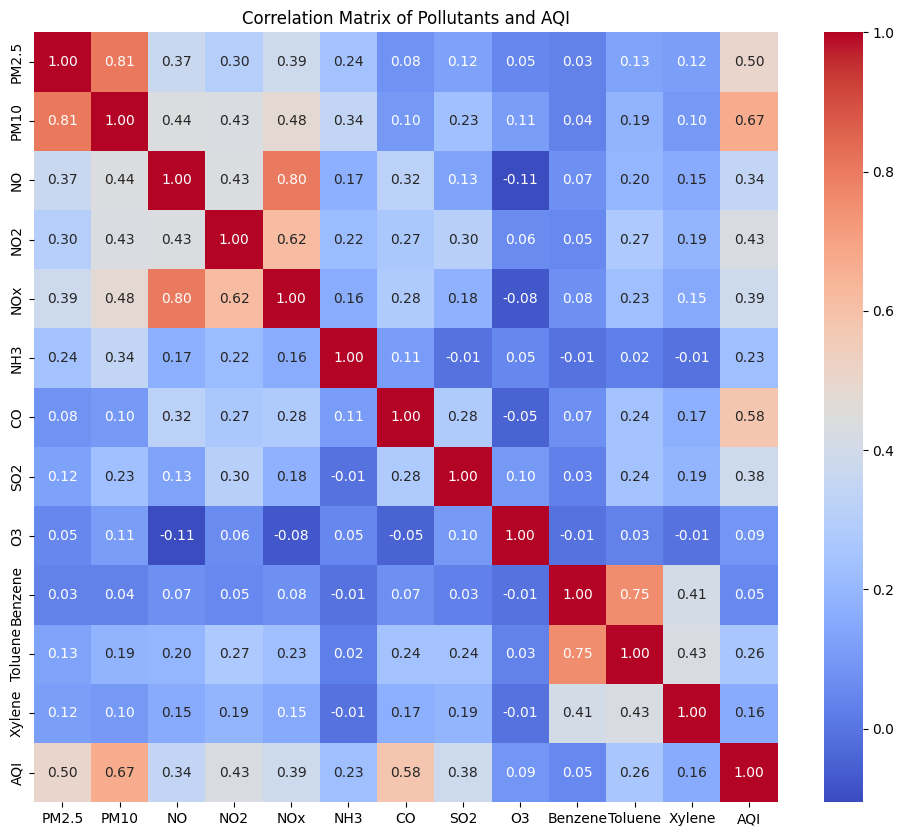

In [19]:
# 2. Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.drop(['City', 'Datetime', 'AQI_Bucket'], axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Pollutants and AQI')
plt.savefig('aqi_correlation_heatmap-before feature engineering.png')
plt.show()

## Data Cleaning

In [20]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [21]:
# Define pollutant columns for cleaning
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

In [22]:
# Remove physically impossible values (negatives)
df[pollutants] = df[pollutants].clip(lower=0)

In [23]:
# Process city-by-city to maintain spatial integrity
cleaned_list = []
unique_cities = df['City'].unique()

for city in unique_cities:
    city_df = df[df['City'] == city].copy()
    city_df = city_df.drop_duplicates(subset='Datetime').sort_values('Datetime')

    city_df = city_df.set_index('Datetime')
    full_hourly_range = pd.date_range(start=city_df.index.min(), end=city_df.index.max(), freq='h')
    city_df = city_df.reindex(full_hourly_range)

    city_df['City'] = city

    city_df[pollutants] = city_df[pollutants].interpolate(method='linear', limit=4)

    city_df[pollutants] = city_df[pollutants].ffill().bfill()

    city_df['AQI_Bucket'] = city_df['AQI_Bucket'].ffill().bfill()

    city_df = city_df.reset_index().rename(columns={'index': 'Datetime'})
    cleaned_list.append(city_df)

In [24]:
# Recombine into a master cleaned dataset
df_cleaned = pd.concat(cleaned_list, ignore_index=True)

In [25]:
# Final step: Remove rows where AQI is still NaN
df_cleaned = df_cleaned.dropna(subset=['AQI'])

In [26]:
print("Cleaned Dataset Shape:", df_cleaned.shape)

Cleaned Dataset Shape: (707875, 16)


In [27]:
df_cleaned

,Datetime,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,2015-01-01 01:00:00,Ahmedabad,36.60,120.06,1.00,40.01,36.37,NaN,1.00,122.070,153.580,0.0,0.0,0.0,288.0,Poor
1,2015-01-01 02:00:00,Ahmedabad,36.60,120.06,0.02,27.75,19.73,NaN,0.02,85.900,153.580,0.0,0.0,0.0,288.0,Poor
2,2015-01-01 03:00:00,Ahmedabad,36.60,120.06,0.08,19.32,11.08,NaN,0.08,52.830,153.580,0.0,0.0,0.0,288.0,Poor
3,2015-01-01 04:00:00,Ahmedabad,36.60,120.06,0.30,16.45,9.20,NaN,0.30,39.530,153.580,0.0,0.0,0.0,288.0,Poor
4,2015-01-01 05:00:00,Ahmedabad,36.60,120.06,0.12,14.90,7.85,NaN,0.12,32.630,108.915,0.0,0.0,0.0,288.0,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707870,2020-06-30 20:00:00,Visakhapatnam,9.50,36.00,2.75,25.57,15.85,4.57,0.62,1.935,27.750,0.0,0.0,0.0,51.0,Satisfactory
707871,2020-06-30 21:00:00,Visakhapatnam,17.25,49.25,3.62,33.20,20.62,3.78,0.76,2.020,25.580,0.0,0.0,0.0,51.0,Satisfactory
707872,2020-06-30 22:00:00,Visakhapatnam,36.00,71.00,2.20,30.80,18.20,3.67,0.58,1.770,26.150,0.0,0.0,0.0,50.0,Good
707873,2020-06-30 23:00:00,Visakhapatnam,15.75,63.00,1.02,28.90,16.00,3.80,0.49,0.750,15.820,0.0,0.0,0.0,50.0,Good


## Time Series Feature Engineering

In [28]:
#1. Cyclical Time Encoding
df_cleaned['Hour'] = df_cleaned['Datetime'].dt.hour
df_cleaned['Month'] = df_cleaned['Datetime'].dt.month

df_cleaned['Hour_sin'] = np.sin(2 * np.pi * df_cleaned['Hour'] / 24)
df_cleaned['Hour_cos'] = np.cos(2 * np.pi * df_cleaned['Hour'] / 24)
df_cleaned['Month_sin'] = np.sin(2 * np.pi * df_cleaned['Month'] / 12)
df_cleaned['Month_cos'] = np.cos(2 * np.pi * df_cleaned['Month'] / 12)

In [29]:
# We group by City to ensure windows don't overlap across different cities
df_cleaned = df_cleaned.sort_values(['City', 'Datetime'])

In [30]:
# Daily Trend and Volatility for PM2.5
df_cleaned['PM2.5_24h_Mean'] = df_cleaned.groupby('City')['PM2.5'].transform(lambda x: x.rolling(window=24).mean())
df_cleaned['PM2.5_24h_Std'] = df_cleaned.groupby('City')['PM2.5'].transform(lambda x: x.rolling(window=24).std())

In [31]:
# Daily Trend for NO2
df_cleaned['NO2_24h_Mean'] = df_cleaned.groupby('City')['NO2'].transform(lambda x: x.rolling(window=24).mean())

In [32]:
# --- 3. Lag Features
# t-1 (previous hour), t-6 (quarter day), t-24 (same time yesterday)
df_cleaned['PM2.5_Lag_1h'] = df_cleaned.groupby('City')['PM2.5'].shift(1)
df_cleaned['PM2.5_Lag_6h'] = df_cleaned.groupby('City')['PM2.5'].shift(6)
df_cleaned['PM2.5_Lag_24h'] = df_cleaned.groupby('City')['PM2.5'].shift(24)

In [33]:
# --- 4. Differencing (Stationarity) ---
# Captures the "rate of change" in pollution
df_cleaned['PM2.5_Diff_1h'] = df_cleaned.groupby('City')['PM2.5'].diff(1)

In [34]:
# Drop rows where rolling/lag results are NaN (first 24h of each city's data)
df_engineered = df_cleaned.dropna()

In [35]:
print(f"Number of features after engineering: {len(df_engineered.columns)}")

Number of features after engineering: 29


In [36]:
df_engineered

,Datetime,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Hour_cos,Month_sin,Month_cos,PM2.5_24h_Mean,PM2.5_24h_Std,NO2_24h_Mean,PM2.5_Lag_1h,PM2.5_Lag_6h,PM2.5_Lag_24h,PM2.5_Diff_1h
50896,2017-11-25 17:00:00,Amaravati,72.75,120.25,1.50,26.72,15.45,10.78,0.10,16.030,...,-2.588190e-01,-5.000000e-01,0.866025,77.906250,9.425282,20.029167,70.00,82.75,60.50,2.75
50897,2017-11-25 18:00:00,Amaravati,81.50,134.75,1.10,18.78,10.88,14.73,0.10,12.930,...,-1.836970e-16,-5.000000e-01,0.866025,78.572917,9.068723,19.803333,72.75,79.00,65.50,8.75
50898,2017-11-25 19:00:00,Amaravati,85.00,142.50,1.62,26.20,15.27,14.50,0.20,12.900,...,2.588190e-01,-5.000000e-01,0.866025,78.781250,9.159906,19.845833,81.50,73.75,80.00,3.50
50899,2017-11-25 20:00:00,Amaravati,91.50,145.75,0.98,18.88,10.83,14.12,0.20,15.220,...,5.000000e-01,-5.000000e-01,0.866025,79.197917,9.509714,19.955417,85.00,68.50,81.50,6.50
50900,2017-11-25 21:00:00,Amaravati,92.50,131.25,0.55,21.35,11.80,12.23,0.10,17.450,...,7.071068e-01,-5.000000e-01,0.866025,79.916667,9.844350,20.116667,91.50,69.25,75.25,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707870,2020-06-30 20:00:00,Visakhapatnam,9.50,36.00,2.75,25.57,15.85,4.57,0.62,1.935,...,5.000000e-01,1.224647e-16,-1.000000,16.156250,9.620464,27.500000,8.25,10.75,11.75,1.25
707871,2020-06-30 21:00:00,Visakhapatnam,17.25,49.25,3.62,33.20,20.62,3.78,0.76,2.020,...,7.071068e-01,1.224647e-16,-1.000000,16.218750,9.622582,28.085417,9.50,15.75,15.75,7.75
707872,2020-06-30 22:00:00,Visakhapatnam,36.00,71.00,2.20,30.80,18.20,3.67,0.58,1.770,...,8.660254e-01,1.224647e-16,-1.000000,16.895833,10.420485,28.699167,17.25,14.00,19.75,18.75
707873,2020-06-30 23:00:00,Visakhapatnam,15.75,63.00,1.02,28.90,16.00,3.80,0.49,0.750,...,9.659258e-01,1.224647e-16,-1.000000,16.635417,10.365332,29.263750,36.00,9.75,22.00,-20.25


In [37]:
df_engineered.columns

Index(['Datetime', 'City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
       'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket',
       'Hour', 'Month', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos',
       'PM2.5_24h_Mean', 'PM2.5_24h_Std', 'NO2_24h_Mean', 'PM2.5_Lag_1h',
       'PM2.5_Lag_6h', 'PM2.5_Lag_24h', 'PM2.5_Diff_1h'],
      dtype='object')

/tmp/ipython-input-590903663.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='magma')


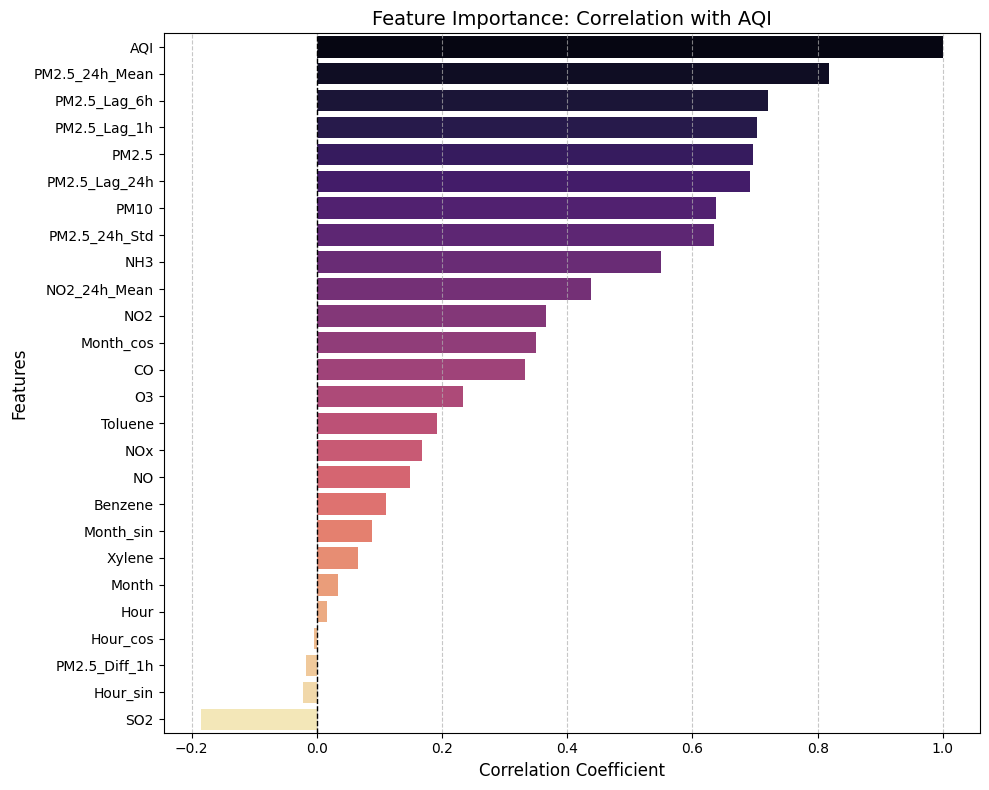

Top 5 Predictive Features:
AQI               1.000000
PM2.5_24h_Mean    0.818483
PM2.5_Lag_6h      0.720885
PM2.5_Lag_1h      0.702515
PM2.5             0.696054
PM2.5_Lag_24h     0.691600
Name: AQI, dtype: float64


In [38]:
target = 'AQI'
features = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene',
    'Hour', 'Month', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos',
    'PM2.5_24h_Mean', 'PM2.5_24h_Std', 'NO2_24h_Mean',
    'PM2.5_Lag_1h', 'PM2.5_Lag_6h', 'PM2.5_Lag_24h',
    'PM2.5_Diff_1h'
]
correlations = df_engineered[features + [target]].corr()[target].sort_values(ascending=False)

# Visualize the importance
plt.figure(figsize=(10, 8))
sns.barplot(x=correlations.values, y=correlations.index, palette='magma')

plt.title('Feature Importance: Correlation with AQI', fontsize=14)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('Feature Importance: Correlation with AQI.png')
plt.show()

print("Top 5 Predictive Features:")
print(correlations.head(6))

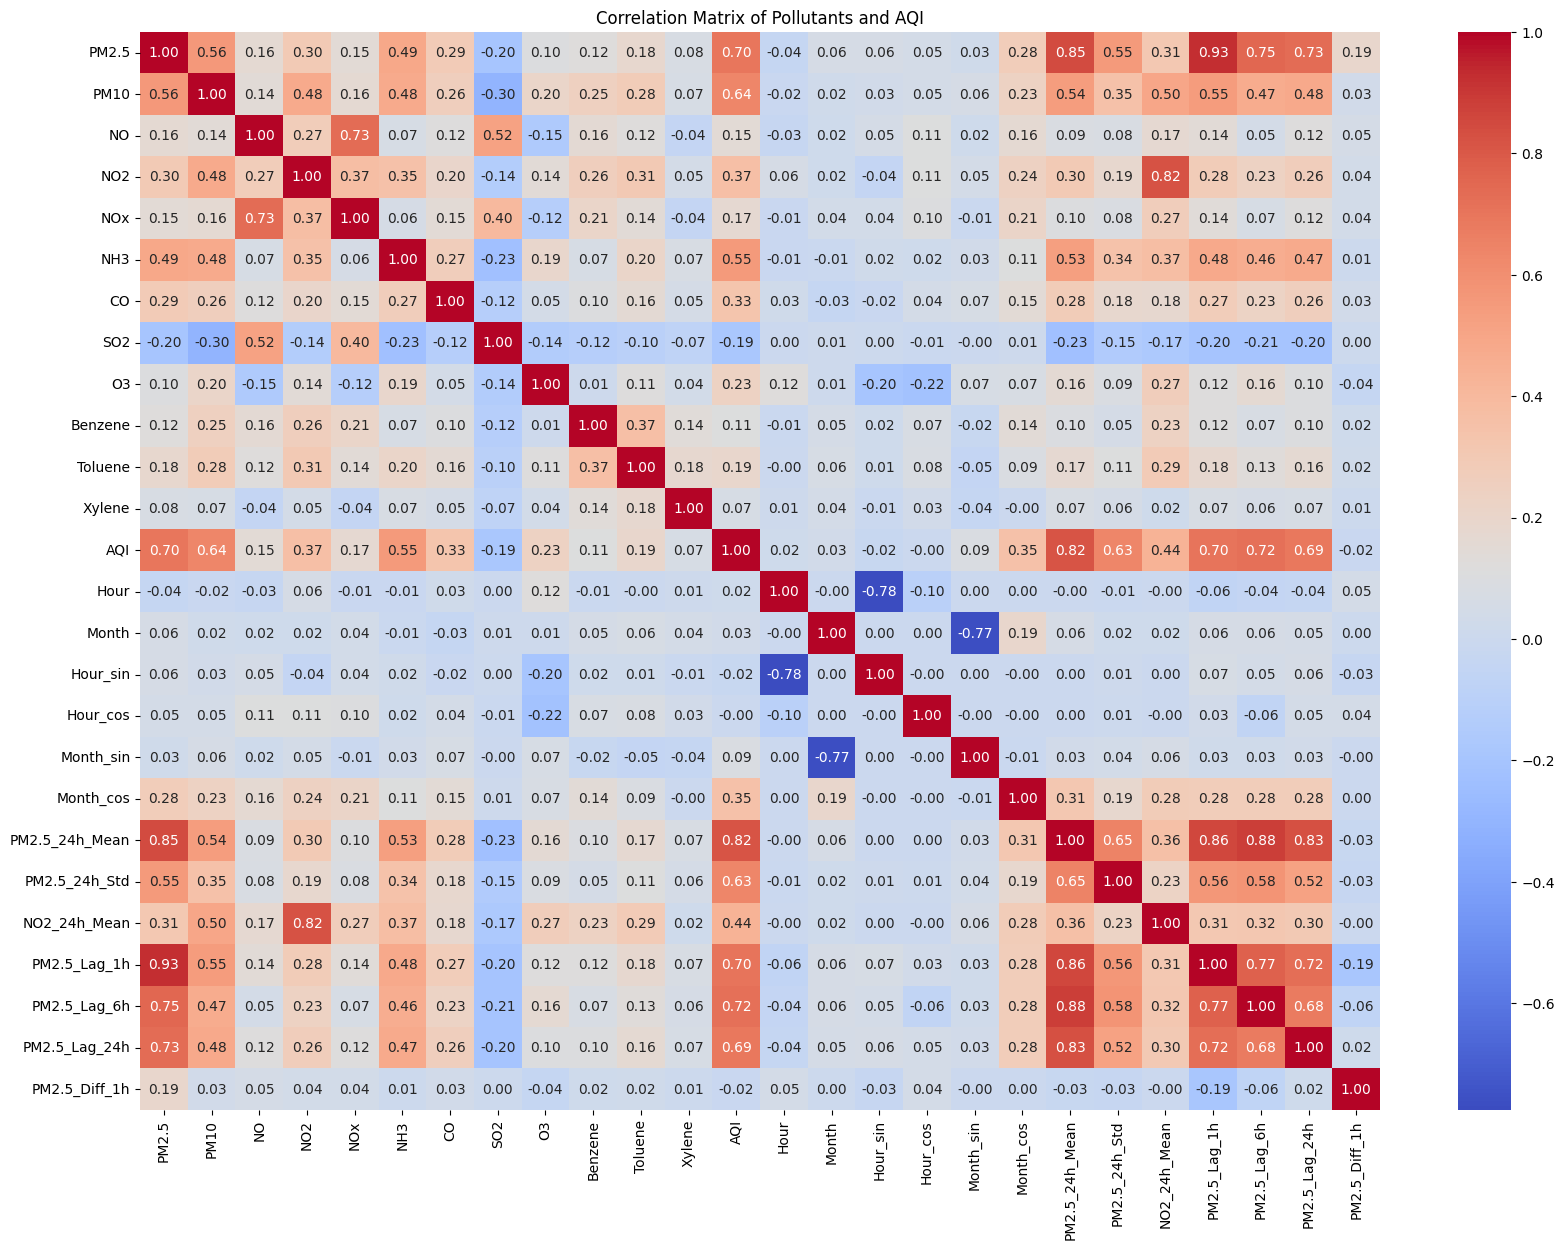

In [39]:
# 2. Correlation Heatmap
plt.figure(figsize=(20, 14))
sns.heatmap(df_engineered.drop(['City', 'Datetime', 'AQI_Bucket'], axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Pollutants and AQI')
plt.savefig('aqi_correlation_heatmap-after feature engineering.png')
plt.show()

## Scaling and Processing for Seq2One

In [40]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

city_name = 'Delhi'
df_city = df[df['City'] == city_name].copy()

# 2. Datetime Conversion & Sorting
df_city['Datetime'] = pd.to_datetime(df_city['Datetime'])
df_city = df_city.sort_values('Datetime').set_index('Datetime')

In [41]:
# Interpolation to fill gaps smoothly
df_city = df_city.interpolate(method='time')
df_city = df_city.dropna()

# Feature Selection
features_to_keep = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
                    'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

available_features = [col for col in features_to_keep if col in df_city.columns]
data = df_city[available_features].values

/tmp/ipython-input-2266818751.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_city = df_city.interpolate(method='time')


In [42]:
# Scaling (Normalization)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# 6. Sequence Creation (Seq2One)
X = []
y = []
n_past = 24

target_col_index = available_features.index('AQI')

for i in range(n_past, len(data_scaled)):
    X.append(data_scaled[i - n_past:i, :])  # Input: Past 24 hours of ALL features
    y.append(data_scaled[i, target_col_index]) # Output: Next hour's AQI

X = np.array(X)
y = np.array(y)

In [43]:
X = []
y = []
n_past = 24   # Input: Past 24 hours
n_future = 4  # Output: Next 4 hours
target_col_index = available_features.index('AQI')

# Loop adjustments to ensure we don't go out of bounds
for i in range(n_past, len(data_scaled) - n_future + 1):
    X.append(data_scaled[i - n_past:i, :])            # Past 24h (all features)
    y.append(data_scaled[i : i + n_future, target_col_index]) # Next 4h (AQI only)

X = np.array(X)
y = np.array(y)

# Train/Test Split (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Adjusted Training Shape: {X_train.shape}")
print(f"Adjusted Target Shape:   {y_train.shape} (Predicting 4 steps)")

Adjusted Training Shape: (38133, 24, 13)
Adjusted Target Shape:   (38133, 4) (Predicting 4 steps)


## LSTM Model Building

In [45]:
!pip install -q -U keras-tuner tf2onnx onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 19.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have proto

In [46]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

In [47]:
# Build the Baseline LSTM Model
baseline_model = Sequential()
baseline_model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
baseline_model.add(Dropout(0.2))
baseline_model.add(LSTM(32, return_sequences=False))
baseline_model.add(Dropout(0.2))
baseline_model.add(Dense(n_future))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
baseline_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

Here it is in clean text format:

Metric: MAE
Good For: Real-world interpretation — “How wrong is the forecast usually?”
Downside: Doesn't punish huge errors heavily.

Metric: RMSE
Good For: Penalizing large errors more than small ones.
Downside: Sensitive to outliers (can be thrown off by one bad prediction).

Metric: MAPE
Good For: Percentage error (%).
Downside: Fails for AQI because if AQI is near 0, the percentage error explodes to infinity.


In [49]:
baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 0.0100 - mae: 0.0638 - val_loss: 3.8763e-04 - val_mae: 0.0154
Epoch 2/10
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0017 - mae: 0.0291 - val_loss: 2.4617e-04 - val_mae: 0.0115
Epoch 3/10
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0011 - mae: 0.0237 - val_loss: 1.8899e-04 - val_mae: 0.0100
Epoch 4/10
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 8.8850e-04 - mae: 0.0211 - val_loss: 1.5124e-04 - val_mae: 0.0088
Epoch 5/10
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 8.1206e-04 - mae: 0.0200 - val_loss: 1.4177e-04 - val_mae: 0.0084
Epoch 6/10
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 7.4769e-04 - mae: 0.0191 - val_loss: 1.2673e-04 - val_mae: 0.0080
Epoch 7/10
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 7.3980e-04 - mae: 0.0189 - val_loss: 1.6643e-04 - val_mae: 0.0103
Epoch 8/10
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 7.1534e-04 - mae: 0.0184 - val_loss: 1.6094e-0

In [50]:
print("Predicting on Test Set...")
y_pred_scaled = baseline_model.predict(X_test)

Predicting on Test Set...
298/298 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [51]:
# 2. Inverse Scaling (Getting back to real AQI values) ---
# We manually reverse the MinMaxScaler equation: X_real = X_scaled * (Max - Min) + Min
# We use the scaler attributes directly to avoid creating large dummy arrays.

# Get the scaling factors specifically for the AQI column
aqi_min = scaler.data_min_[target_col_index]
aqi_range = scaler.data_range_[target_col_index]

# Inverse transform
y_test_actual = y_test * aqi_range + aqi_min
y_pred_actual = y_pred_scaled * aqi_range + aqi_min

print("Prediction range:", y_pred_actual.min(), "to", y_pred_actual.max())

Prediction range: 43.567301750183105 to 767.8960175514221


In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print(f"\nFinal Test Set Metrics (Real AQI Scale):")
print(f"MAE:  {mae:.2f} ")
print(f"RMSE: {rmse:.2f}")


Final Test Set Metrics (Real AQI Scale):
MAE:  5.78 
RMSE: 8.15


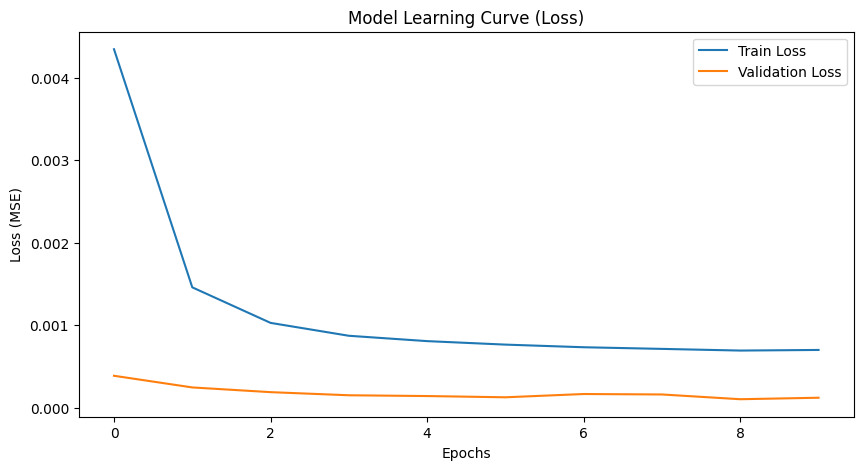

In [56]:
# Plot A: Loss Curves (Did we overfit?)
plt.figure(figsize=(10, 5))
plt.plot(baseline_history.history['loss'], label='Train Loss')
plt.plot(baseline_history.history['val_loss'], label='Validation Loss')
plt.title('Model Learning Curve (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.savefig('Training and Validation Loss for baseline LSTM')
plt.show()

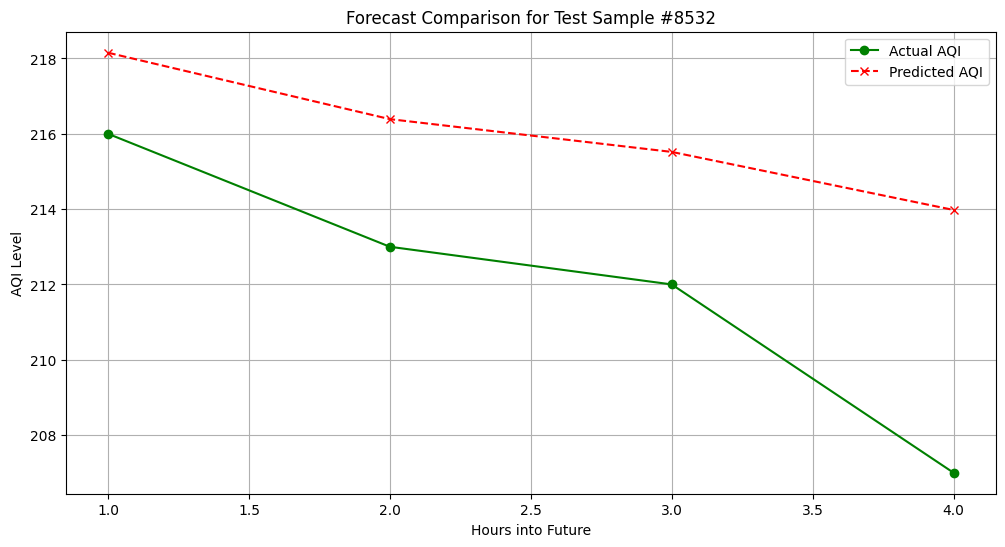

In [63]:
# Actual vs Predicted for a specific sample
# Let's pick a random sample from the test set to visualize the 4-hour forecast
import random
sample_idx = random.randint(0, len(y_test_actual) - 1)

plt.figure(figsize=(12, 6))
hours = [1, 2, 3, 4]

# Plot the actual next 4 hours
plt.plot(hours, y_test_actual[sample_idx], marker='o', label='Actual AQI', color='green')
# Plot the predicted next 4 hours
plt.plot(hours, y_pred_actual[sample_idx], marker='x', linestyle='--', label='Predicted AQI', color='red')

plt.title(f'Forecast Comparison for Test Sample #{sample_idx}')
plt.xlabel('Hours into Future')
plt.ylabel('AQI Level')
plt.legend()
plt.grid(True)
plt.savefig('Forecasting Comparison for a Test Sample')
plt.show()

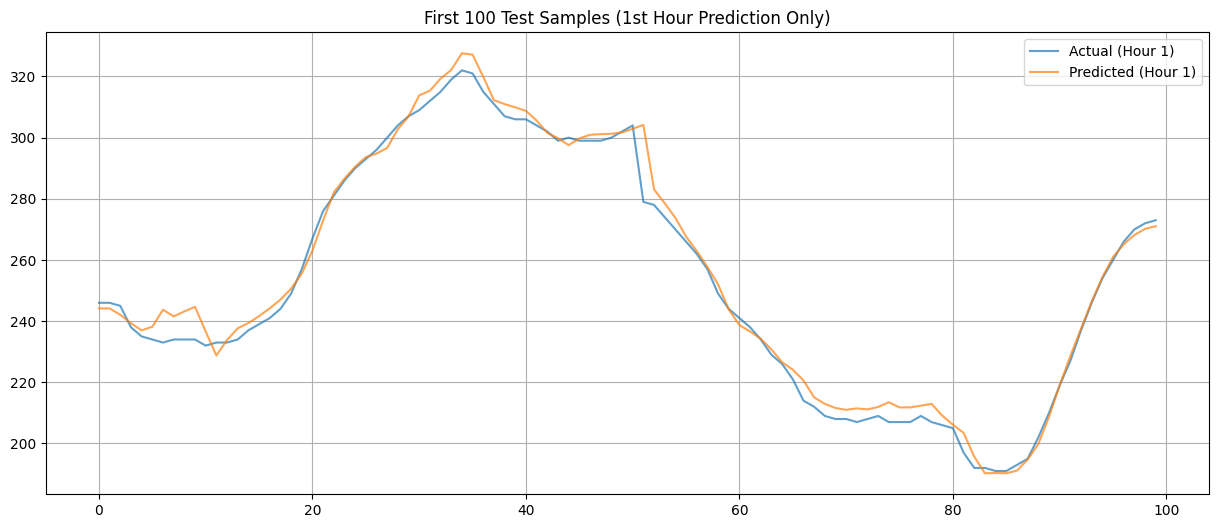

In [65]:
# Overall Comparison (First 100 hours of 1st step prediction)
plt.figure(figsize=(15, 6))
plt.plot(y_test_actual[:100, 0], label='Actual (Hour 1)', alpha=0.7)
plt.plot(y_pred_actual[:100, 0], label='Predicted (Hour 1)', alpha=0.7)
plt.title('First 100 Test Samples (1st Hour Prediction Only)')
plt.legend()
plt.grid(True)
plt.savefig('First 100 Test Samples (1st Hour Prediction Only)')
plt.show()

## Fine Tuning LSTM Model

In [66]:
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam

# Define the model building function for the Tuner
def build_model(hp):
    model = Sequential()

    # Tune first LSTM layer
    model.add(LSTM(units=hp.Int('units_1', min_value=32, max_value=128, step=32),
                   return_sequences=True,
                   input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(hp.Float('dropout_1', 0.1, 0.4, step=0.1)))

    # Tune second LSTM layer
    model.add(LSTM(units=hp.Int('units_2', min_value=16, max_value=64, step=16),
                   return_sequences=False))
    model.add(Dropout(hp.Float('dropout_2', 0.1, 0.4, step=0.1)))

    # Output layer
    model.add(Dense(n_future))

    # Tune learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=Adam(learning_rate=hp_learning_rate),
                  loss='mean_squared_error')
    return model

In [67]:
# Initialize the Tuner (Hyperband is fast)
tuner = kt.Hyperband(build_model,
                     objective='val_loss',
                     max_epochs=10,  # Fast tuning (fewer epochs)
                     factor=3,
                     directory='aqi_tuning_dir',
                     project_name='aqi_forecast')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [68]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)

In [69]:
print("Starting Hyperparameter Tuning...")
tuner.search(X_train, y_train,
             epochs=10,
             validation_data=(X_test, y_test),
             callbacks=[stop_early],
             verbose=1)

Trial 30 Complete [00h 01m 44s]
val_loss: 0.00021162604389246553

Best val_loss So Far: 8.967856410890818e-05
Total elapsed time: 00h 21m 08s


In [70]:
# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBest Parameters Found:")
print(f"- Units Layer 1: {best_hps.get('units_1')}")
print(f"- Units Layer 2: {best_hps.get('units_2')}")
print(f"- Learning Rate: {best_hps.get('learning_rate')}")


Best Parameters Found:
- Units Layer 1: 128
- Units Layer 2: 48
- Learning Rate: 0.001


In [71]:
# Build and Train the Final Best Model
print("Training Final Optimized Model...")
final_model = tuner.hypermodel.build(best_hps)

history = final_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

Training Final Optimized Model...
Epoch 1/30
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0058 - val_loss: 5.1439e-04
Epoch 2/30
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0013 - val_loss: 1.6196e-04
Epoch 3/30
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 8.9720e-04 - val_loss: 1.4692e-04
Epoch 4/30
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 7.5042e-04 - val_loss: 1.2696e-04
Epoch 5/30
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 6.7639e-04 - val_loss: 1.2060e-04
Epoch 6/30
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 6.4415e-04 - val_loss: 1.9353e-04
Epoch 7/30
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 6.1086e-04 - val_loss: 9.5860e-05
Epoch 8/30
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5.9024e-04 - val_loss: 2.0714e-04
Epoch 9/30
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5.6100e-04 - val_loss: 4.2437e-04
Epoch 10/30
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 5.6849e-04 - val_loss: 1.7759e-04
Epoch

In [74]:
import tf2onnx
import onnx
import tensorflow as tf

print("Converting model to ONNX format...")

# 1. Define the input signature
# (Batch_Size=None, Timesteps=24, Features=13)
input_signature = [tf.TensorSpec([None, 24, 13], tf.float32, name='input_features')]

# 2. Convert using 'from_function' (The Fix)
# We wrap the model.call method in a tf.function to make it compatible
tf_function_model = tf.function(lambda x: final_model(x))

onnx_model, _ = tf2onnx.convert.from_function(
    function=tf_function_model,
    input_signature=input_signature,
    opset=13
)

# 3. Save the ONNX file
output_path = "aqi_4hr_forecast_model.onnx"
onnx.save(onnx_model, output_path)

print(f"SUCCESS: Model successfully saved to {output_path}")

Converting model to ONNX format...


ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x7bbc264fb9c0>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.
ERROR:tf2onnx.tfonnx:Tensorflow op [sequential_1_1/lstm_2_1/CudnnRNNV3: CudnnRNNV3] is not supported
ERROR:tf2onnx.tfonnx:Tensorflow op [sequential_1_1/lstm_3_1/CudnnRNNV3: CudnnRNNV3] is not supported
ERROR:tf2onnx.tfonnx:Unsupported ops: Counter({'CudnnRNNV3': 2})


SUCCESS: Model successfully saved to aqi_4hr_forecast_model.onnx


In [76]:
import tensorflow as tf
import numpy as np

# --- 1. Save the Model ---
tf_save_path = "aqi_lstm_saved_model.keras" # Added .keras extension
final_model.save(tf_save_path)
print(f"TensorFlow model saved to: {tf_save_path}")

# --- 2. Load the Model ---
loaded_tf_model = tf.keras.models.load_model(tf_save_path)

# --- 3. Predict using the Loaded Model ---
# Use a sample from your test set (ensure it matches the shape (1, 24, 13))
sample_input = X_test[0:1]
tf_prediction = loaded_tf_model.predict(sample_input)

# Inverse scale to get real AQI
# Note: We use the scaler min/range for the 'AQI' column (target_col_index)
aqi_val = tf_prediction * scaler.data_range_[target_col_index] + scaler.data_min_[target_col_index]

print(f"\nTensorFlow Prediction (Scaled): {tf_prediction[0]}")
print(f"TensorFlow Prediction (Real AQI): {aqi_val[0]}")

TensorFlow model saved to: aqi_lstm_saved_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step

TensorFlow Prediction (Scaled): [0.30484504 0.3049431  0.30565912 0.3082431 ]
TensorFlow Prediction (Real AQI): [247.58532596 247.65790474 248.18774533 250.09989095]


In [77]:
# ensorFlow model to make predictions
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

# Assuming loaded_tf_model, scaler, target_col_index, aqi_min, and aqi_range
# are already available from previous executions. If not, they would need to be re-initialized.

# --- 1. Prepare Input (example using a sample from X_test) ---
# For a real-time prediction, you would get the last 24 hours of data for a specific city,
# preprocess it (handle missing values, engineer features, scale), and shape it as (1, 24, 13).
# For this example, we'll use an existing sample from X_test.

# Get a sample input (e.g., the first sample from the test set)
input_for_prediction = X_test[0:1] # Shape (1, 24, 13)

print(f"Input shape for prediction: {input_for_prediction.shape}")

# --- 2. Make Prediction ---
# The model predicts the scaled AQI values for the next 4 hours
predicted_scaled_aqi = loaded_tf_model.predict(input_for_prediction)

# --- 3. Inverse Scale Prediction to Real AQI Values ---
# We need to use the min/max values of the AQI column from the original scaler
# to inverse transform the predictions.

# (Assuming aqi_min and aqi_range are available from previous steps)
# If not, they would need to be re-calculated based on the original data's AQI column
# For example:
# aqi_min = scaler.data_min_[target_col_index]
# aqi_range = scaler.data_range_[target_col_index]

predicted_real_aqi = predicted_scaled_aqi * aqi_range + aqi_min

print(f"\nPredicted Scaled AQI for next 4 hours: {predicted_scaled_aqi[0]}")
print(f"Predicted Real AQI for next 4 hours: {predicted_real_aqi[0]}")

Input shape for prediction: (1, 24, 13)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Predicted Scaled AQI for next 4 hours: [0.30484504 0.3049431  0.30565912 0.3082431 ]
Predicted Real AQI for next 4 hours: [247.58532596 247.65790474 248.18774533 250.09989095]


In [79]:
!pip install onnxruntime

import onnxruntime as ort
import numpy as np

print("Loading ONNX model and preparing for inference...")

# 1. Load the ONNX model
onnx_model_path = "aqi_4hr_forecast_model.onnx"
sess = ort.InferenceSession(onnx_model_path)

# Get input and output names
input_name = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

print(f"Input name: {input_name}, Output name: {output_name}")

# 2. Prepare Input Data
# Use a sample from X_test, ensuring it's float32 and matches the expected input shape (1, 24, 13)
input_for_onnx_prediction = X_test[0:1].astype(np.float32)

print(f"Input shape for ONNX prediction: {input_for_onnx_prediction.shape}")

# 3. Make Prediction with ONNX Runtime
onnx_predictions_scaled = sess.run([output_name], {input_name: input_for_onnx_prediction})[0]

# 4. Inverse Scale Prediction to Real AQI Values
# Reuse aqi_min and aqi_range from previous execution
predicted_real_aqi_onnx = onnx_predictions_scaled * aqi_range + aqi_min

print(f"\nONNX Predicted Scaled AQI for next 4 hours: {onnx_predictions_scaled[0]}")
print(f"ONNX Predicted Real AQI for next 4 hours: {predicted_real_aqi_onnx[0]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 99.6 MB/s eta 0:00:00
Loading ONNX model and preparing for inference...


InvalidGraph: [ONNXRuntimeError] : 10 : INVALID_GRAPH : Load model from aqi_4hr_forecast_model.onnx failed:This is an invalid model. In Node, ("sequential_1_1/lstm_2_1/CudnnRNNV3", CudnnRNNV3, "", -1) : ("input_features": tensor(float),"sequential_1_1/lstm_2_1/ExpandDims:0": tensor(float),"sequential_1_1/lstm_2_1/ExpandDims:0": tensor(float),"sequential_1_1/lstm_2_1/concat_1:0": tensor(float),"sequential_1_1/lstm_2_1/Fill:0": tensor(int32),) -> ("sequential_1_1/lstm_2_1/CudnnRNNV3:0","sequential_1_1/lstm_2_1/CudnnRNNV3:1","sequential_1_1/lstm_2_1/CudnnRNNV3:2","sequential_1_1/lstm_2_1/CudnnRNNV3:3","sequential_1_1/lstm_2_1/CudnnRNNV3:4",) , Error No Op registered for CudnnRNNV3 with domain_version of 13

The ONNX model failed to load due to CudnnRNNV3 operations, which are not directly supported by tf2onnx and ONNX Runtime. To resolve this, I need to modify the LSTM layers in your model to use a non-CuDNN implementation that is more compatible with ONNX conversion